# Batch Inference

This notebook shows how to run Migas-1.5 on **multiple time series** in a single `predict()` call and how to iterate over a directory of CSV files to collect forecasts.

**Requirements:** Install the package (`uv sync`). For live summarization a vLLM server must be running; to skip it, pass `summaries=` (see the [Offline Summaries](migas-1.5-offline-summaries.ipynb) notebook).

**Data:** Download prepared FNSPID CSVs and summaries:
```bash
uv run python scripts/download_fnspid.py --all
```

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import json, os
import numpy as np
import pandas as pd
import torch
from migaseval import MigasPipeline, list_data_files

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = MigasPipeline.from_pretrained("Synthefy/migas-1.5", device=device)
print(f"Using device: {device}")

Loading Chronos-2 on device: cuda:0
Loading TimesFM 2.5...
Downloaded.
Compiling model...
TimesFM 2.5 loaded
Initialized univariate models: chronos, timesfm (prophet on-demand)
Using device: cuda


## Batching multiple samples in one call

`predict()` accepts a batch dimension: `context` has shape `(B, T)` and `text` is a list of B lists. This is more efficient than calling `predict()` in a loop.

In [3]:
csv_dir = "../data/fnspid_prepared/fnspid_0.5_complement_csvs"
csv_files = list_data_files(csv_dir)[:4]  # first 4 datasets
print(f"Using {len(csv_files)} datasets: {[os.path.basename(f) for f in csv_files]}")

seq_len = 384
pred_len = 16

contexts = []
texts = []
names = []

for path in csv_files:
    df = pd.read_csv(path)
    df = df.head(seq_len)
    contexts.append(df["y_t"].values.astype(np.float32))
    texts.append(df["text"].fillna("").astype(str).tolist())
    names.append(os.path.splitext(os.path.basename(path))[0])

context_batch = np.stack(contexts)  # (B, seq_len)
print(f"Batch context shape: {context_batch.shape}")

Using 4 datasets: ['abbv_with_text.csv', 'abt_with_text.csv', 'adbe_with_text.csv', 'amat_with_text.csv']
Batch context shape: (4, 384)


In [4]:
forecast_batch = pipeline.predict(context_batch, texts, pred_len=pred_len)
print(f"Batch forecast shape: {forecast_batch.shape}")  # (B, pred_len, 1)

Batch forecast shape: torch.Size([4, 16, 1])


## Plotting batch results

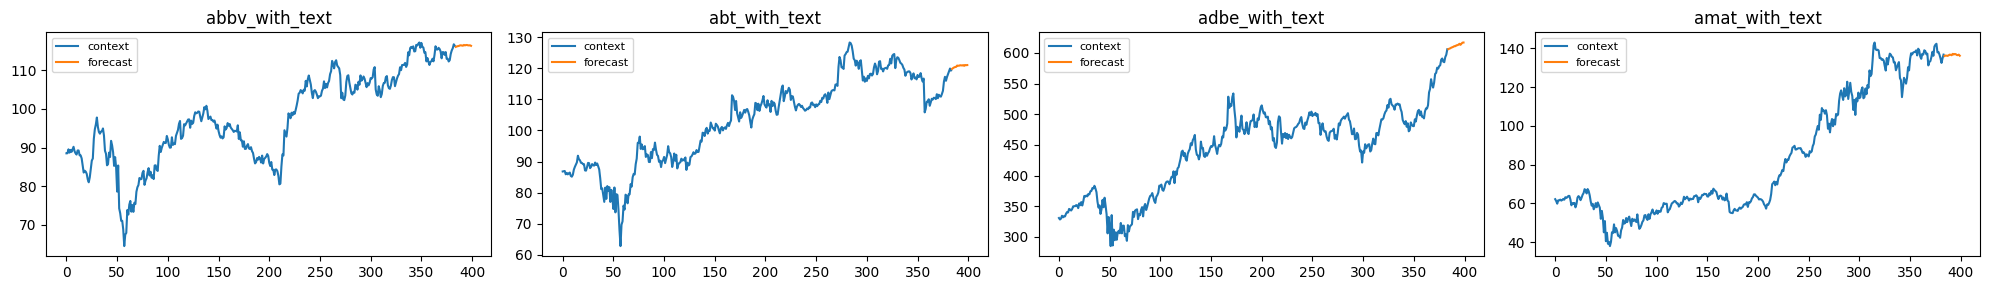

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 3), sharey=False)
if len(names) == 1:
    axes = [axes]

for i, (name, ax) in enumerate(zip(names, axes)):
    ctx = contexts[i]
    pred = forecast_batch[i, :, 0].detach().cpu().numpy()
    ax.plot(np.arange(len(ctx)), ctx, label="context")
    ax.plot(np.arange(len(ctx), len(ctx) + pred_len), pred, label="forecast")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Iterating over a directory with pre-computed summaries

For large-scale runs you'll typically loop over files and collect results. Using pre-computed summaries avoids the LLM bottleneck.

In [6]:
csv_dir = "../data/fnspid_prepared/fnspid_0.5_complement_csvs"
summaries_root = "../data/fnspid_prepared/fnspid_0.5_complement"

results = []

for csv_path in list_data_files(csv_dir)[:8]:
    name = os.path.splitext(os.path.basename(csv_path))[0]
    summary_path = os.path.join(summaries_root, name, "summary_0.json")

    if not os.path.exists(summary_path):
        print(f"  Skipping {name} (no summary found)")
        continue

    df = pd.read_csv(csv_path)
    with open(summary_path) as f:
        summary = json.load(f)["summary"]

    forecast = pipeline.predict_from_dataframe(
        df, pred_len=pred_len, seq_len=seq_len, summaries=[summary]
    )
    results.append({"dataset": name, "forecast": forecast.tolist()})
    print(f"  {name}: forecast={forecast[:3]}...")

print(f"\nCollected forecasts for {len(results)} datasets.")

  abbv_with_text: forecast=[154.21558 154.43893 154.5064 ]...
  abt_with_text: forecast=[107.05564  107.134705 107.131714]...
  adbe_with_text: forecast=[589.1801  589.95605 591.5771 ]...
  amat_with_text: forecast=[160.76465 161.08762 161.09068]...
  Skipping amd_with_text (no summary found)
  Skipping biib_with_text (no summary found)
  Skipping bntx_with_text (no summary found)
  Skipping cmcsa_with_text (no summary found)

Collected forecasts for 4 datasets.


## Collecting results into a DataFrame

In [7]:
rows = []
for r in results:
    for step, val in enumerate(r["forecast"]):
        rows.append({"dataset": r["dataset"], "step": step, "forecast": val})

results_df = pd.DataFrame(rows)
print(results_df.head(20))

# Optionally save
# results_df.to_csv("forecasts.csv", index=False)

           dataset  step    forecast
0   abbv_with_text     0  154.215576
1   abbv_with_text     1  154.438934
2   abbv_with_text     2  154.506393
3   abbv_with_text     3  154.636765
4   abbv_with_text     4  154.694733
5   abbv_with_text     5  154.903030
6   abbv_with_text     6  154.927521
7   abbv_with_text     7  154.959579
8   abbv_with_text     8  154.860764
9   abbv_with_text     9  154.948257
10  abbv_with_text    10  154.940125
11  abbv_with_text    11  155.143036
12  abbv_with_text    12  154.921753
13  abbv_with_text    13  154.986923
14  abbv_with_text    14  155.039001
15  abbv_with_text    15  154.989883
16   abt_with_text     0  107.055641
17   abt_with_text     1  107.134705
18   abt_with_text     2  107.131714
19   abt_with_text     3  107.231079
